In [1]:
import numpy as np
import pandas as pd
import joblib
import time
import re
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, auc


In [2]:
model = joblib.load("phishing_random_forest.pkl")
print("Model loaded successfully")


Model loaded successfully


In [2]:
phishing_urls = [
    "http://secure-paypal-login.com",
    "http://verify-account-now.net",
    "http://update-bank-details.org",
    "http://192.168.1.1/login",
    "http://login-facebook-security.com",
    "http://free-gift-card-offer.com",
    "http://confirm-payment-immediately.net",
    "http://account-verification-required.com",
    "http://secure-amazon-login.net",
    "http://paypal.com.verify.user.session.co"
]

legitimate_urls = [
    "https://www.google.com",
    "https://www.youtube.com",
    "https://www.amazon.com",
    "https://www.microsoft.com",
    "https://www.apple.com",
    "https://www.wikipedia.org",
    "https://www.linkedin.com",
    "https://www.github.com",
    "https://www.stackoverflow.com",
    "https://www.netflix.com"
]


In [7]:
urls = phishing_urls + legitimate_urls
true_labels = [1]*len(phishing_urls) + [0]*len(legitimate_urls)


In [9]:
print("Average prediction time (seconds):", np.mean(times))


NameError: name 'np' is not defined

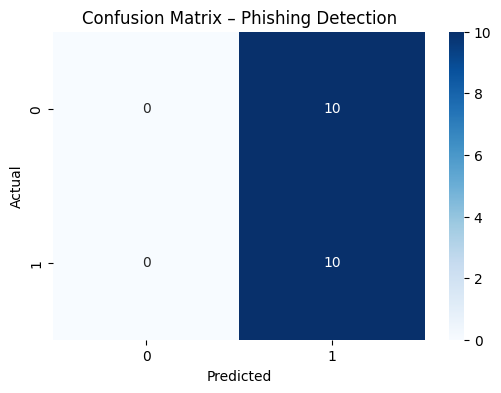

In [9]:
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Phishing Detection")
plt.show()


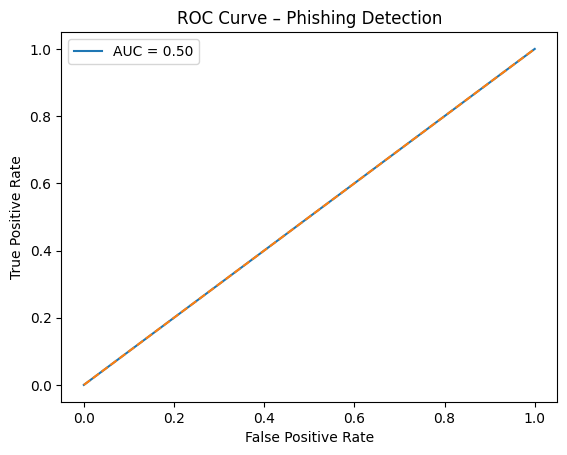

In [10]:
fpr, tpr, _ = roc_curve(true_labels, predictions)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Phishing Detection")
plt.legend()
plt.show()


In [11]:
accuracy = np.mean(np.array(predictions) == np.array(true_labels))
print("Accuracy:", accuracy)


Accuracy: 0.5


In [12]:
from collections import Counter
print("Prediction counts:", Counter(predictions))
print("True label counts:", Counter(true_labels))


Prediction counts: Counter({np.int64(1): 20})
True label counts: Counter({1: 10, 0: 10})


In [3]:
import numpy as np
import pandas as pd
import joblib
import time
import re
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, auc


In [4]:
model = joblib.load("phishing_random_forest.pkl")
print("Model loaded successfully")


Model loaded successfully


In [5]:
def extract_features(url):
    features = []

    features.append(1 if re.search(r"\d+\.\d+\.\d+\.\d+", url) else 0)
    features.append(len(url))
    features.append(url.count('-'))
    features.append(url.count('@'))
    features.append(url.count('?'))
    features.append(url.count('%'))
    features.append(url.count('='))

    features.append(0 if url.startswith("https") else 1)

    keywords = ["login", "verify", "secure", "update", "bank", "free"]
    features.append(1 if any(word in url.lower() for word in keywords) else 0)

    while len(features) < 49:
        features.append(0)

    return features


In [6]:
phishing_urls = [
    "http://secure-paypal-login.com",
    "http://verify-account-now.net",
    "http://update-bank-details.org",
    "http://192.168.1.1/login",
    "http://login-facebook-security.com",
    "http://free-gift-card-offer.com",
    "http://confirm-payment-immediately.net",
    "http://account-verification-required.com",
    "http://paypal.com.verify.user.session.co"
]

legitimate_urls = [
    "https://www.google.com",
    "https://www.youtube.com",
    "https://www.amazon.com",
    "https://www.microsoft.com",
    "https://www.apple.com",
    "https://www.wikipedia.org",
    "https://www.linkedin.com",
    "https://www.github.com",
    "https://www.stackoverflow.com",
    "https://www.netflix.com"
]


In [7]:
urls = phishing_urls + legitimate_urls
true_labels = [1]*len(phishing_urls) + [0]*len(legitimate_urls)


In [8]:
predictions = []
times = []

for url in urls:
    start = time.time()

    features = extract_features(url)
    features = np.array(features).reshape(1, -1)

    pred = model.predict(features)[0]

    end = time.time()

    predictions.append(pred)
    times.append(end - start)


C:\Users\Arnav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Arnav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Arnav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Arnav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-pac

In [9]:
print("Average prediction time (seconds):", np.mean(times))


Average prediction time (seconds): 0.008634190810354133


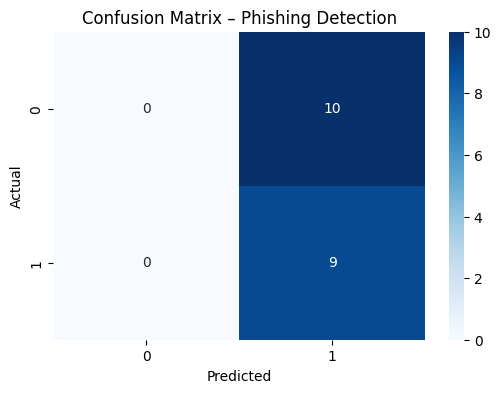

In [10]:
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Phishing Detection")
plt.show()


In [11]:
accuracy = np.mean(np.array(predictions) == np.array(true_labels))
print("Accuracy:", accuracy)


Accuracy: 0.47368421052631576


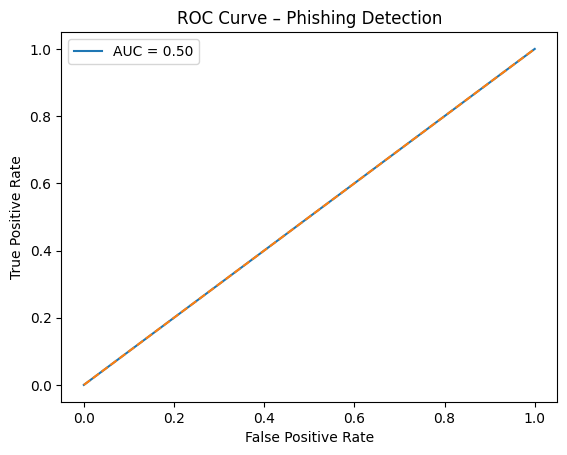

In [12]:
fpr, tpr, _ = roc_curve(true_labels, predictions)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Phishing Detection")
plt.legend()
plt.show()


In [2]:
import numpy as np
import pandas as pd
import joblib
import time
import re
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, auc


In [3]:
model = joblib.load("phishing_random_forest.pkl")
print("Model loaded successfully")


Model loaded successfully


In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [11]:
accuracy = np.mean(np.array(predictions) == np.array(true_labels))
print("Accuracy:", accuracy)


NameError: name 'predictions' is not defined

In [12]:
df = pd.read_csv("../dataset/phishing.csv")   # replace with your dataset name

In [13]:
df.head()

,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,...,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,...,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,...,0,0,0,1,0,-1,1,-1,0,1
3,4,3,1,6,79,1,0,0,0,0,...,0,0,0,1,-1,1,1,1,-1,1
4,5,3,0,4,46,0,0,0,0,0,...,1,0,0,1,1,-1,0,-1,-1,1


In [14]:
X = df.drop("CLASS_LABEL", axis=1)
y = df["CLASS_LABEL"]

In [15]:
X = df.drop("CLASS_LABEL", axis=1)
y = df["CLASS_LABEL"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
print(X_train.shape)
print(X_test.shape)

(8000, 49)
(2000, 49)


In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 1.0


In [20]:
print(X.columns)

Index(['id', 'NumDots', 'SubdomainLevel', 'PathLevel', 'UrlLength', 'NumDash',
       'NumDashInHostname', 'AtSymbol', 'TildeSymbol', 'NumUnderscore',
       'NumPercent', 'NumQueryComponents', 'NumAmpersand', 'NumHash',
       'NumNumericChars', 'NoHttps', 'RandomString', 'IpAddress',
       'DomainInSubdomains', 'DomainInPaths', 'HttpsInHostname',
       'HostnameLength', 'PathLength', 'QueryLength', 'DoubleSlashInPath',
       'NumSensitiveWords', 'EmbeddedBrandName', 'PctExtHyperlinks',
       'PctExtResourceUrls', 'ExtFavicon', 'InsecureForms',
       'RelativeFormAction', 'ExtFormAction', 'AbnormalFormAction',
       'PctNullSelfRedirectHyperlinks', 'FrequentDomainNameMismatch',
       'FakeLinkInStatusBar', 'RightClickDisabled', 'PopUpWindow',
       'SubmitInfoToEmail', 'IframeOrFrame', 'MissingTitle',
       'ImagesOnlyInForm', 'SubdomainLevelRT', 'UrlLengthRT',
       'PctExtResourceUrlsRT', 'AbnormalExtFormActionR', 'ExtMetaScriptLinkRT',
       'PctExtNullSelfRedirectHyperl

In [21]:
print(X.columns)

Index(['id', 'NumDots', 'SubdomainLevel', 'PathLevel', 'UrlLength', 'NumDash',
       'NumDashInHostname', 'AtSymbol', 'TildeSymbol', 'NumUnderscore',
       'NumPercent', 'NumQueryComponents', 'NumAmpersand', 'NumHash',
       'NumNumericChars', 'NoHttps', 'RandomString', 'IpAddress',
       'DomainInSubdomains', 'DomainInPaths', 'HttpsInHostname',
       'HostnameLength', 'PathLength', 'QueryLength', 'DoubleSlashInPath',
       'NumSensitiveWords', 'EmbeddedBrandName', 'PctExtHyperlinks',
       'PctExtResourceUrls', 'ExtFavicon', 'InsecureForms',
       'RelativeFormAction', 'ExtFormAction', 'AbnormalFormAction',
       'PctNullSelfRedirectHyperlinks', 'FrequentDomainNameMismatch',
       'FakeLinkInStatusBar', 'RightClickDisabled', 'PopUpWindow',
       'SubmitInfoToEmail', 'IframeOrFrame', 'MissingTitle',
       'ImagesOnlyInForm', 'SubdomainLevelRT', 'UrlLengthRT',
       'PctExtResourceUrlsRT', 'AbnormalExtFormActionR', 'ExtMetaScriptLinkRT',
       'PctExtNullSelfRedirectHyperl

In [22]:

print(df.duplicated().sum())

0


In [23]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.769  1.     1.     1.     0.7765]
Average CV Score: 0.9091000000000001


In [24]:
print(X.shape)

(10000, 49)


In [25]:
print("Label in X:", "CLASS_LABEL" in X.columns)

Label in X: False
